In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-meas',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_meas',
        '--data_nsample', '144',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '128',
        '--nlayer_stat', '3',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [21]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.251153, valid=0.074247, test=0.077982
	validation loss decreased (inf -> 0.074247), saving model ...
	epoch 2 losses: train=0.241679, valid=0.073131, test=0.076793
	validation loss decreased (0.074247 -> 0.073131), saving model ...
	epoch 3 losses: train=0.233631, valid=0.076202, test=0.079922
	early stopping counter: 1 out of 30
	epoch 4 losses: train=0.232961, valid=0.074324, test=0.077434
	early stopping counter: 2 out of 30
	epoch 5 losses: train=0.229680, valid=0.073692, test=0.076693
	early stopping counter: 3 out of 30
	epoch 6 losses: train=0.226887, valid=0.075027, test=0.077653
	early stopping counter: 4 out of 30
	epoch 7 losses: train=0.226907, valid=0.073840, test=0.077288
	early stopping counter: 5 out of 30
	epoch 8 losses: train=0.227140, valid=0.075835, test=0.079108
	early stopping counter: 6 out of 30
	epoch 9 losses: train=0.224438, valid=0.075178, test=0.079482
	early stopping counter: 7 out of 30
	epoch 10 los

In [22]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

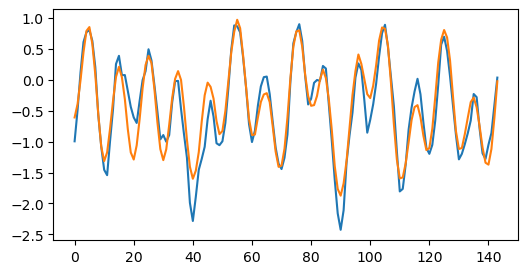

In [23]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [24]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.569896, valid=0.579784, test=0.391332
	validation loss decreased (inf -> 0.579784), saving model ...
	epoch 2 losses: train=0.462003, valid=0.482853, test=0.320584
	validation loss decreased (0.579784 -> 0.482853), saving model ...
	epoch 3 losses: train=0.409606, valid=0.466897, test=0.311427
	validation loss decreased (0.482853 -> 0.466897), saving model ...
	epoch 4 losses: train=0.398742, valid=0.471528, test=0.312490
	early stopping counter: 1 out of 30
	epoch 5 losses: train=0.389257, valid=0.459489, test=0.306518
	validation loss decreased (0.466897 -> 0.459489), saving model ...
	epoch 6 losses: train=0.383805, valid=0.453090, test=0.309301
	validation loss decreased (0.459489 -> 0.453090), saving model ...
	epoch 7 losses: train=0.382745, valid=0.455399, test=0.291869
	early stopping counter: 1 out of 30
	epoch 8 losses: train=0.375854, valid=0.452615, test=0.310133
	validation loss decreased (0.453090 -> 0.452615),

In [25]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

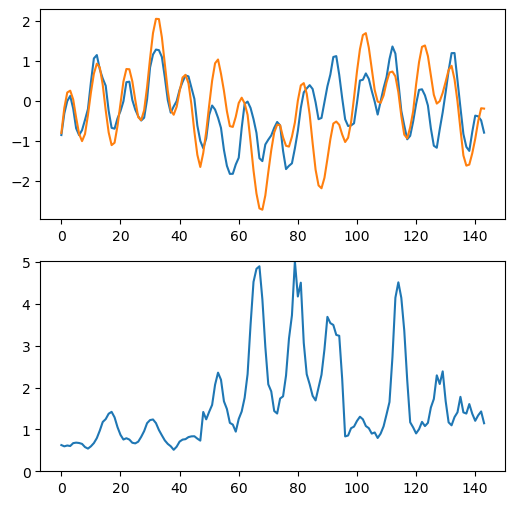

In [32]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [33]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.356205, valid=0.617184, test=0.625427
	validation loss decreased (inf -> 0.617184), saving model ...
	epoch 2 losses: train=0.732461, valid=0.428077, test=0.428013
	validation loss decreased (0.617184 -> 0.428077), saving model ...
	epoch 3 losses: train=0.522986, valid=0.286776, test=0.286062
	validation loss decreased (0.428077 -> 0.286776), saving model ...
	epoch 4 losses: train=0.391121, valid=0.264529, test=0.263686
	validation loss decreased (0.286776 -> 0.264529), saving model ...
	epoch 5 losses: train=0.362570, valid=0.243489, test=0.243937
	validation loss decreased (0.264529 -> 0.243489), saving model ...
	epoch 6 losses: train=0.344290, valid=0.236509, test=0.237828
	validation loss decreased (0.243489 -> 0.236509), saving model ...
	epoch 7 losses: train=0.331955, valid=0.234218, test=0.234692
	validation loss decreased (0.236509 -> 0.234218), saving model ...
	epoch 8 losses: train=0.322611, valid=0.230855, test=0.230

In [36]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

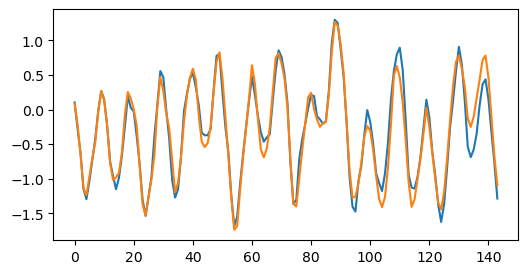

In [58]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [59]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.336522, valid=-0.046451, test=0.034451
	validation loss decreased (inf -> -0.046451), saving model ...
	epoch 2 losses: train=-0.113441, valid=-0.108633, test=-0.026082
	validation loss decreased (-0.046451 -> -0.108633), saving model ...
	epoch 3 losses: train=-0.179936, valid=-0.204007, test=0.385243
	validation loss decreased (-0.108633 -> -0.204007), saving model ...
	epoch 4 losses: train=4.059006, valid=-0.214551, test=-0.105726
	validation loss decreased (-0.204007 -> -0.214551), saving model ...
	epoch 5 losses: train=-0.210661, valid=-0.111839, test=-0.049550
	early stopping counter: 1 out of 30
	epoch 6 losses: train=-0.219413, valid=-0.217412, test=-0.179212
	validation loss decreased (-0.214551 -> -0.217412), saving model ...
	epoch 7 losses: train=-0.252269, valid=-0.145542, test=-0.120406
	early stopping counter: 1 out of 30
	epoch 8 losses: train=-0.267215, valid=-0.190374, test=-0.138016
	early stopping counte

In [60]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

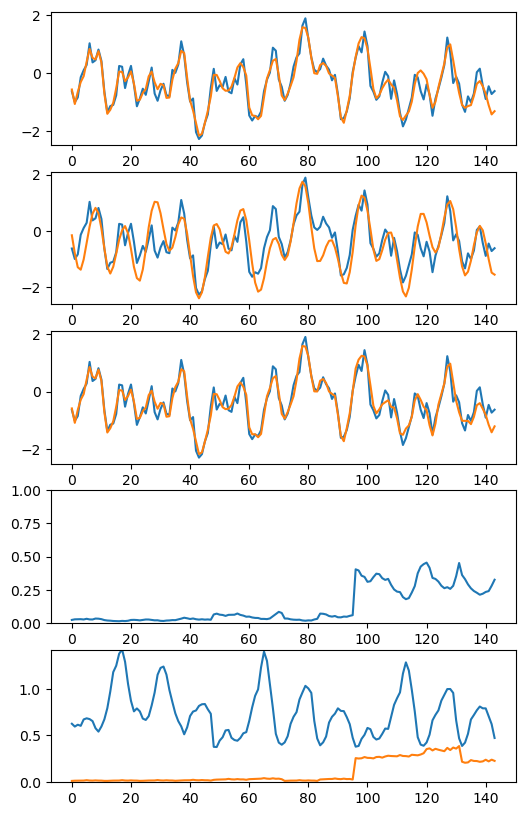

In [62]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break